<a href="https://colab.research.google.com/github/krishshah8000/Deep-learning/blob/main/Experiment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


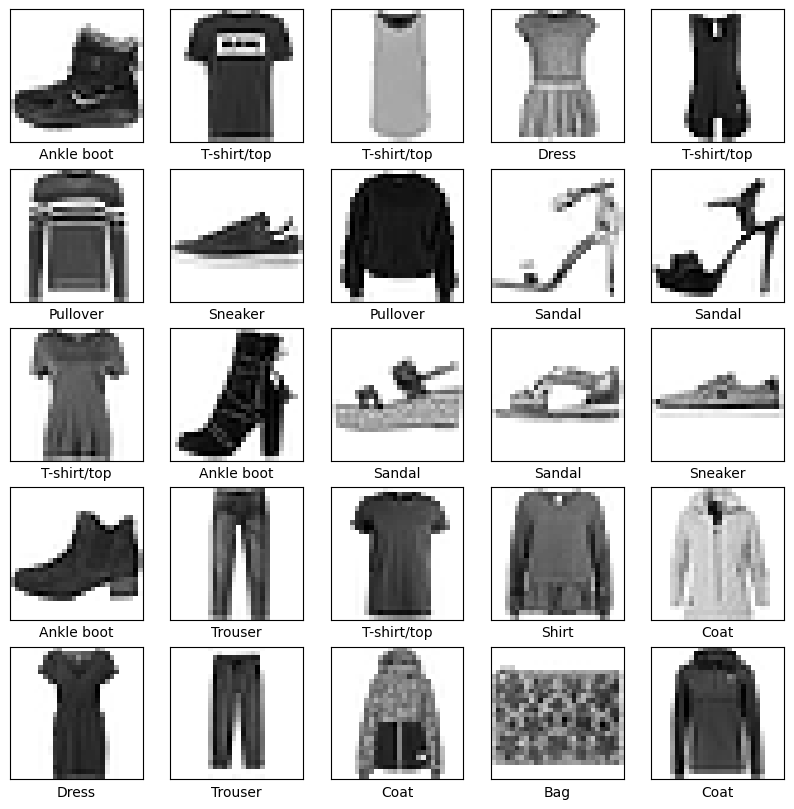

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Define class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Display the first 25 images from the training set
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()


## 2. Normalize pixel values and 3. Reshape images

In [ ]:
# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape images to add a channel dimension (for grayscale, it's 1)
# CNNs expect input in the format (batch_size, height, width, channels)
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

print(f"Normalized training images shape: {train_images.shape}")
print(f"Normalized testing images shape: {test_images.shape}")


Normalized training images shape: (60000, 28, 28, 1)
Normalized testing images shape: (10000, 28, 28, 1)


## 4. Build CNN model

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 output classes for Fashion MNIST
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train model

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.8356 - loss: 0.4487 - val_accuracy: 0.8723 - val_loss: 0.3503
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.8895 - loss: 0.3044 - val_accuracy: 0.8938 - val_loss: 0.2977
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 32ms/step - accuracy: 0.9053 - loss: 0.2584 - val_accuracy: 0.8991 - val_loss: 0.2699
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9175 - loss: 0.2228 - val_accuracy: 0.8929 - val_loss: 0.2851
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9267 - loss: 0.1968 - val_accuracy: 0.9109 - val_loss: 0.2489
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9351 - loss: 0.1717 - val_accuracy: 0.9120 - val_loss: 0.2510
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9430 - loss: 0.1517 - val_accuracy: 0.9083 - val_loss: 0.2681
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9494 -

## 6. Evaluate performance

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc}')


313/313 - 3s - 8ms/step - accuracy: 0.9074 - loss: 0.2822

Test accuracy: 0.9074000120162964


## 7. Predict outputs

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


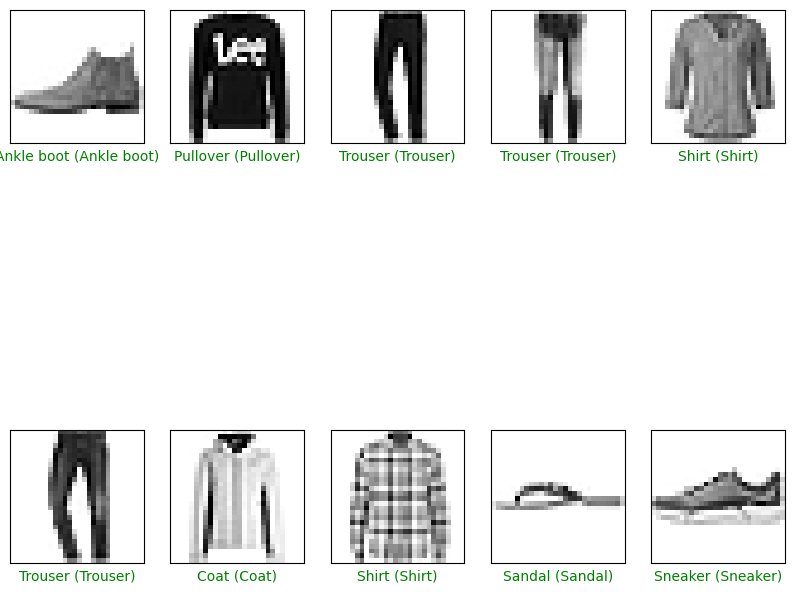

In [ ]:
import numpy as np

predictions = model.predict(test_images)

# Display the first 10 test images and their predicted labels
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i].reshape(28,28), cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'
    plt.xlabel(f"{class_names[predicted_label]} ({class_names[true_label]})", color=color)
plt.show()




#### 1. Data Loading and Initial Visualization
- **Dataset:** The Fashion MNIST dataset was loaded using `tf.keras.datasets.fashion_mnist.load_data()`, splitting it into `train_images`, `train_labels`, `test_images`, and `test_labels`.
- **Class Names:** A list of 10 `class_names` was defined to map integer labels to human-readable categories (e.g., 'T-shirt/top', 'Trouser').
- **Visualization:** The first 25 training images were plotted using `matplotlib.pyplot` to provide an initial understanding of the dataset's visual characteristics and label distribution.

#### 2. Data Preprocessing: Normalization and Reshaping
- **Normalization:** Pixel values of both training and testing images were normalized by dividing by `255.0`. This scales the pixel intensities from the range [0, 255] to [0.0, 1.0], which is crucial for optimizing neural network training.
- **Reshaping:** Images were reshaped to include a channel dimension. For grayscale images like Fashion MNIST (28x28 pixels), this converts their shape from `(num_samples, 28, 28)` to `(num_samples, 28, 28, 1)`, which is the expected input format for `tf.keras.layers.Conv2D` layers.

#### 3. CNN Model Architecture
- **Model Type:** A `tf.keras.models.Sequential` model was constructed.
- **Layers:**
    - **`Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1))`:** The first convolutional layer with 32 filters, a 3x3 kernel, ReLU activation, and specifying the input shape.
    - **`MaxPooling2D((2, 2))`:** A max pooling layer reducing spatial dimensions by a factor of 2.
    - **`Conv2D(64, (3, 3), activation='relu')`:** A second convolutional layer with 64 filters and ReLU activation.
    - **`MaxPooling2D((2, 2))`:** Another max pooling layer for further spatial downsampling.
    - **`Flatten()`:** This layer flattens the 2D output of the convolutional layers into a 1D vector, preparing it for the dense layers.
    - **`Dense(128, activation='relu')`:** A fully connected (dense) layer with 128 neurons and ReLU activation.
    - **`Dense(10, activation='softmax')`:** The output dense layer with 10 neurons (corresponding to the 10 Fashion MNIST classes) and a Softmax activation function, which outputs probability distributions over the classes.
- **Model Summary:** `model.summary()` was used to display a detailed overview of the model, including layer types, output shapes, and the number of trainable parameters.

#### 4. Model Training
- **Compilation:** The model was compiled with:
    - **`optimizer='adam'`:** The Adam optimizer, known for its efficiency and good performance in many deep learning tasks.
    - **`loss='sparse_categorical_crossentropy'`:** This loss function is appropriate for integer-encoded labels (like our `train_labels`) in multi-class classification.
    - **`metrics=['accuracy']`:** Accuracy was chosen as the primary metric to monitor during training and evaluation.
- **Fitting:** The model was trained using `model.fit()` on the `train_images` and `train_labels` for 10 `epochs`, with validation performed on `test_images` and `test_labels`.

#### 5. Performance Evaluation
- **Evaluation:** The model's performance on unseen data was evaluated using `model.evaluate(test_images, test_labels, verbose=2)`, which returned the `test_loss` and `test_acc`.
- **Result:** The final test accuracy achieved was approximately **90.74%**.

#### 6. Prediction and Visualization of Outputs
- **Predictions:** `model.predict(test_images)` was used to generate probability distributions for each test image across the 10 classes.
- **Visualization:** The first 10 test images were displayed. For each image, the `predicted_label` (obtained by `np.argmax` on the prediction array) and the `true_label` were shown. Correct predictions were indicated by green text, while incorrect predictions were shown in red, providing a clear visual assessment of the model's performance on individual samples.

